## DS 4420 Project

### Kuan-Chun Chiu, Pual Champagne
### Prof. Gerber
### DS 4420
### 12/05/2025

#### Import all needed libraries

In [15]:
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from datetime import datetime
import pandas as pd
import numpy as np

#### Load the economic indicator and S&P 500 datasets

In [2]:
indicator_df = pd.read_csv("macro_indicators_data.csv")

print (f"Shape of the indicator df: {indicator_df.shape}")
indicator_df.head()

Shape of the indicator df: (5757, 10)


,Date,NFP_actual,NFP_forecast,NFP_surprise,Core CPE_actual,Core CPE_forecast,Core CPE_surprise,Core Retail Sales_actual,Core Retail Sales_forecast,Core Retail Sales_surprise
0,2009-12-23,NaN,NaN,NaN,0.0,0.001,-0.001,NaN,NaN,NaN
1,2009-12-24,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2009-12-25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2009-12-26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2009-12-27,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
stock_df = pd.read_csv("sp500_hist_returns.csv")
stock_df.rename(columns={"date": "Date"}, inplace=True)

print (f"Shape of the S&P 500 df: {stock_df.shape}")
stock_df.head()

Shape of the S&P 500 df: (4004, 8)


,Date,open,high,low,close,pct_change,volume,ln_return
0,2025-11-18,6641.19,6666.63,6574.32,6617.32,-0.0083,3206050763,-0.008289
1,2025-11-17,6713.61,6754.50,6638.90,6672.40,-0.0092,3074772162,-0.009206
2,2025-11-14,6672.14,6774.31,6646.87,6734.11,-0.0005,3079987673,-0.000512
3,2025-11-13,6826.47,6828.05,6724.72,6737.56,-0.0166,3327416477,-0.016695
4,2025-11-12,6867.77,6869.91,6829.62,6850.99,0.0006,2893216944,0.000640


#### Data preprocessing

In [4]:
kept_columns = ["Date", "ln_return"]
stock_df = stock_df[kept_columns]

surprise_columns = [column for column in indicator_df.columns if "surprise" in column]
kept_columns = ["Date"] + surprise_columns
indicator_df = indicator_df[kept_columns]
indicator_df[surprise_columns] = indicator_df[surprise_columns].fillna(0)

merged_df = indicator_df.merge(stock_df, on="Date", how="inner")
scaler = StandardScaler()
merged_df[surprise_columns] = scaler.fit_transform(merged_df[surprise_columns])

print (f"Shape of the merged df: {merged_df.shape}")
merged_df.head()

Shape of the merged df: (3965, 5)


,Date,NFP_surprise,Core CPE_surprise,Core Retail Sales_surprise,ln_return
0,2009-12-23,-0.020026,-6.219787,-0.000426,0.002296
1,2009-12-24,-0.020026,0.055393,-0.000426,0.005242
2,2009-12-28,-0.020026,0.055393,-0.000426,0.001153
3,2009-12-29,-0.020026,0.055393,-0.000426,-0.001402
4,2009-12-30,-0.020026,0.055393,-0.000426,0.000195


#### Create X matrix and y (target) array

In [5]:
y = merged_df["ln_return"].to_numpy()
X = merged_df[surprise_columns].to_numpy()
bias_column = np.ones(len(X), dtype="float").reshape(-1, 1)
X = np.concatenate((bias_column, X), axis=1)

print (f"X matrix shape: {X.shape}")
print (f"y array shape: {y.shape}\n")
print (f"First 5 rows of X matrix: \n{X[:5]}\n")
print (f"First 5 values of y array: \n{y[:5]}")

X matrix shape: (3965, 4)
y array shape: (3965,)

First 5 rows of X matrix: 
[[ 1.00000000e+00 -2.00257263e-02 -6.21978721e+00 -4.25579639e-04]
 [ 1.00000000e+00 -2.00257263e-02  5.53925070e-02 -4.25579639e-04]
 [ 1.00000000e+00 -2.00257263e-02  5.53925070e-02 -4.25579639e-04]
 [ 1.00000000e+00 -2.00257263e-02  5.53925070e-02 -4.25579639e-04]
 [ 1.00000000e+00 -2.00257263e-02  5.53925070e-02 -4.25579639e-04]]

First 5 values of y array: 
[ 0.00229607  0.00524239  0.00115337 -0.00140197  0.00019533]


#### Create training and testing subset

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, shuffle=False)

print (f"Shape of trainning X matrix: {X_train.shape}")
print (f"Shape of testing X matrix: {X_test.shape}")
print (f"Shape of training y array: {y_train.shape}")
print (f"Shape of testing y array: {y_test.shape}")

Shape of trainning X matrix: (2973, 4)
Shape of testing X matrix: (992, 4)
Shape of training y array: (2973,)
Shape of testing y array: (992,)


#### Define prior distribution

In [7]:
alpha = 0.001
feature_num = X_train.shape[1]

identity = np.eye(feature_num)
identity[0, 0] = 0
prior_cov = (1/alpha) * identity
prior_cov[0, 0] = np.inf
prior_mean = np.zeros(feature_num).reshape(-1, 1)

print (f"Prior distribution mean: \n{prior_mean}\n")
print (f"Prior distribution covariance matrix: \n{prior_cov}")

Prior distribution mean: 
[[0.]
 [0.]
 [0.]
 [0.]]

Prior distribution covariance matrix: 
[[  inf    0.    0.    0.]
 [   0. 1000.    0.    0.]
 [   0.    0. 1000.    0.]
 [   0.    0.    0. 1000.]]


#### Define posterior distribution

In [8]:
data_std = np.std(y_train)

mean_part_1 = np.matmul(X_train.T, y_train).reshape(-1, 1)
mean_part_2 = np.matmul(X_train.T, X_train)
mean_part_3 = ((data_std**2)/alpha) * identity
mean_part_4 = np.linalg.inv(mean_part_2 + mean_part_3)
posterior_mean = np.matmul(mean_part_4, mean_part_1)

cov_part_1 = np.matmul(X_train.T, X_train)
cov_part_2 = ((data_std**2)/alpha) * identity
cov_part_3 = np.linalg.inv(cov_part_1 + cov_part_2)
posterior_cov = (data_std**2) * cov_part_3

print (f"Posterior distribution mean: \n{posterior_mean}\n")
print (f"Posterior distribution covariance matrix: \n{posterior_cov}")

Posterior distribution mean: 
[[0.00045908]
 [0.00048281]
 [0.00015374]
 [0.00011777]]

Posterior distribution covariance matrix: 
[[ 3.98037504e-08 -8.01805495e-11  4.70319366e-10  1.23002180e-10]
 [-8.01805495e-11  3.00251999e-08 -6.57285968e-11 -1.87175800e-12]
 [ 4.70319366e-10 -6.57285968e-11  3.86909310e-08  7.14396689e-12]
 [ 1.23002180e-10 -1.87175800e-12  7.14396689e-12  3.33164629e-08]]


#### Making predictions

In [9]:
prediction_mean = np.matmul(X_test, posterior_mean)
prediction_cov = data_std**2 + np.matmul(X_test, (np.matmul(posterior_cov, X_test.T)))

print (f"Shape of prediction mean: {prediction_mean.shape}")
print (f"Shape of prediction covariance matrix: {prediction_cov.shape}")

Shape of prediction mean: (992, 1)
Shape of prediction covariance matrix: (992, 992)


In [10]:
weight_sample_num = 1000

weight_samples = np.random.multivariate_normal(
    mean = posterior_mean.flatten(),
    cov = posterior_cov,
    size = weight_sample_num
)

print (f"Shape of weight/coefficient samples: {weight_samples.shape}")

Shape of weight/coefficient samples: (1000, 4)


In [11]:
prediction_samples = np.matmul(X_test, weight_samples.T)
prediction_samples += np.random.normal(
    loc = 0,
    scale = data_std,
    size = prediction_samples.shape
)

print (f"Shape of prediction samples: {prediction_samples.shape}")

Shape of prediction samples: (992, 1000)


In [12]:
predictions = [row.mean() for row in prediction_samples]
first_10_predictions = [value.item() for value in predictions[:10]]

print (f"Number of predictions made: {len(predictions)}\n")
print (f"First 10 prediction values: \n{first_10_predictions}")

Number of predictions made: 992

First 10 prediction values: 
[0.0005666830533474324, 0.0012876662014276237, -0.0002825106468243633, -0.0005067958467621736, 0.0005197556514376986, 0.0005294269863721639, 0.001380735961675441, 0.0002470972987132876, 0.0007818973780526038, 0.0003236818902882697]


#### Plotting prediction VS Actual S&P 500 returns

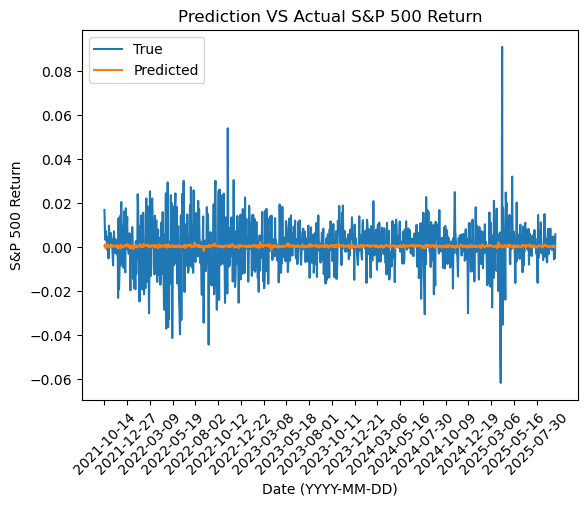

In [13]:
x_axis_dates = merged_df["Date"][len(X_train):]

plt.plot(x_axis_dates, y_test, label="True")
plt.plot(x_axis_dates, predictions, label="Predicted")
plt.title("Prediction VS Actual S&P 500 Return")
plt.xlabel("Date (YYYY-MM-DD)")
plt.ylabel("S&P 500 Return")
plt.xticks(x_axis_dates[::50], rotation=45)
plt.legend()
plt.show()

#### Assessing model performance

In [18]:
mse = round(mean_squared_error(y_test, predictions), 6)
r2 = round(r2_score(y_test, predictions), 3)

print (f"MSE of the prediction: {mse}")
print (f"R2 score of the prediction: {r2}")

MSE of the prediction: 0.000128
R2 score of the prediction: -0.004


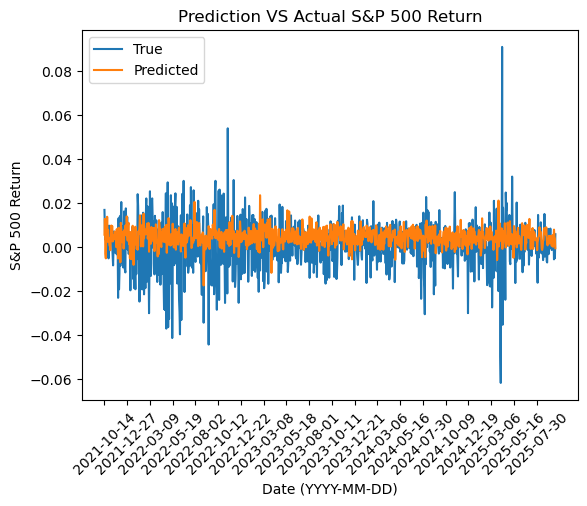

In [22]:
# The result only looked legit when I scaled the prediction 10 times larger, which is of course not right but just to let you see the effect.

plt.plot(x_axis_dates, y_test, label="True")
plt.plot(x_axis_dates, [p*10 for p in predictions], label="Predicted")
plt.title("Prediction VS Actual S&P 500 Return")
plt.xlabel("Date (YYYY-MM-DD)")
plt.ylabel("S&P 500 Return")
plt.xticks(x_axis_dates[::50], rotation=45)
plt.legend()
plt.show()